# 1.1 Was ist Machine Learning? — Lösung

Dieses Notebook gehört zu **Lektion 1.1** auf der Kurs-Website.

Du wirst
1. einen echten Datensatz als Matrix `X` und Vektor `y` kennenlernen,
2. dein erstes scikit-learn-Modell trainieren und bewerten,
3. den k-Nächste-Nachbarn-Algorithmus selbst implementieren,
4. sehen, wie der Hyperparameter `k` Over- und Underfitting steuert.

Zellen mit `# TODO` sind deine Aufgaben. Die Lösung liegt im Ordner `loesungen/`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (7, 4)
rng = np.random.default_rng(42)

## 1. Der Datensatz

Der **Iris-Datensatz** enthält 150 Blüten von drei Schwertlilien-Arten. Für jede Blüte sind vier Merkmale gemessen
(Länge und Breite von Kelch- und Blütenblatt, in cm). Er ist in scikit-learn eingebaut.

In [2]:
from sklearn.datasets import load_iris

iris = load_iris()
X, y = iris.data, iris.target
print("Feature-Namen:", iris.feature_names)
print("Klassen:      ", iris.target_names)
print("X:", X.shape, " y:", y.shape)
print(X[:5])
print(y[:5])

Feature-Namen: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Klassen:       ['setosa' 'versicolor' 'virginica']
X: (150, 4)  y: (150,)
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]
[0 0 0 0 0]


**Aufgabe 1.1:** Beantworte mit Code:
- Wie viele Beispiele und wie viele Features gibt es?
- Wie viele Beispiele hat jede Klasse? (Tipp: `np.bincount`)

In [3]:
# Anzahl Beispiele und Features aus X.shape auslesen
n_beispiele, n_features = X.shape
# Anzahl Beispiele pro Klasse zählen
pro_klasse = np.bincount(y)
print(n_beispiele, n_features, pro_klasse)

150 4 [50 50 50]


Zwei Features lassen sich als Punktwolke zeichnen. Jede Farbe ist eine Klasse – das sind die **Labels**.

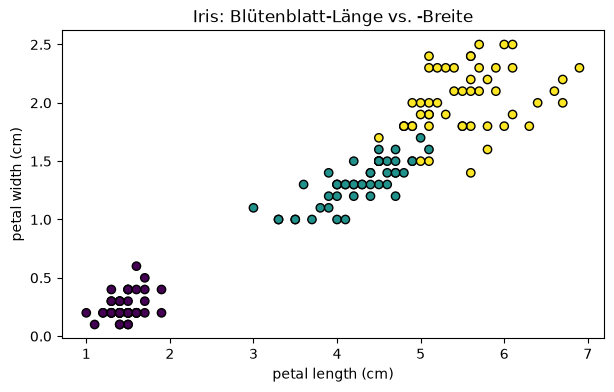

In [4]:
plt.scatter(X[:, 2], X[:, 3], c=y, cmap="viridis", edgecolor="k")
plt.xlabel(iris.feature_names[2]); plt.ylabel(iris.feature_names[3])
plt.title("Iris: Blütenblatt-Länge vs. -Breite")
plt.show()

## 2. Dein erstes Modell mit scikit-learn

Jedes scikit-learn-Modell folgt demselben Muster:

```python
model = Modellklasse(hyperparameter=...)
model.fit(X_train, y_train)      # Training
y_pred = model.predict(X_test)   # Inferenz
```

Damit wir ehrlich messen, teilen wir die Daten in **Training** und **Test**. Das Modell sieht die Testdaten beim Training nie.

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0, stratify=y)
print(X_train.shape, X_test.shape)

(105, 4) (45, 4)


**Aufgabe 2.1:** Trainiere einen `KNeighborsClassifier` mit `n_neighbors=5` und berechne die Genauigkeit (Anteil richtiger Vorhersagen) auf den Testdaten.

In [6]:
# Modell erzeugen und trainieren
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)
# Vorhersagen für X_test berechnen und Genauigkeit bestimmen
y_pred = model.predict(X_test)
genauigkeit = np.mean(y_pred == y_test)
print(f"Genauigkeit: {genauigkeit:.3f}")

Genauigkeit: 1.000


## 3. k-Nächste-Nachbarn selbst bauen

Der Algorithmus ist verblüffend einfach:
1. Berechne die Distanz vom neuen Punkt zu **allen** Trainingspunkten.
2. Nimm die `k` Punkte mit der kleinsten Distanz.
3. Sage die Klasse vorher, die unter diesen `k` am häufigsten vorkommt.

Das "Training" besteht nur darin, die Daten zu speichern.

In [7]:
class MeinKNN:
    def __init__(self, k=5):
        self.k = k

    def fit(self, X, y):
        # Trainingsdaten speichern
        self.X_train = X
        self.y_train = y
        return self

    def predict_one(self, x):
        # Euklidische Distanzen von x zu allen Trainingspunkten (ohne Schleife!)
        distanzen = np.sqrt(((self.X_train - x) ** 2).sum(axis=1))
        # Indizes der k kleinsten Distanzen (Tipp: np.argsort)
        naechste = np.argsort(distanzen)[: self.k]
        # Häufigste Klasse unter den Nachbarn (Tipp: np.bincount + argmax)
        return np.bincount(self.y_train[naechste]).argmax()

    def predict(self, X):
        return np.array([self.predict_one(x) for x in X])


mein = MeinKNN(k=5).fit(X_train, y_train)
meine_pred = mein.predict(X_test)
print("Meine Genauigkeit:  ", np.mean(meine_pred == y_test))
print("Stimmt mit sklearn überein:", np.all(meine_pred == y_pred))

Meine Genauigkeit:   1.0
Stimmt mit sklearn überein: True


## 4. Over- und Underfitting

Wir messen die Genauigkeit auf Trainings- **und** Testdaten für verschiedene `k`.

**Aufgabe 4.1:** Fülle die beiden Listen und betrachte das Diagramm. Bei welchem `k` ist der Abstand zwischen Training und Test am größten? Was passiert bei sehr großem `k`?

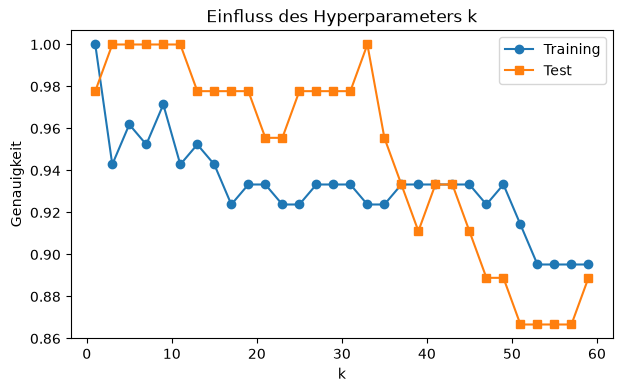

In [8]:
ks = list(range(1, 60, 2))
train_acc, test_acc = [], []
for k in ks:
    # Modell mit k Nachbarn trainieren, Genauigkeit auf Training und Test anhängen
    m = KNeighborsClassifier(n_neighbors=k).fit(X_train, y_train)
    train_acc.append(m.score(X_train, y_train))
    test_acc.append(m.score(X_test, y_test))

plt.plot(ks, train_acc, "o-", label="Training")
plt.plot(ks, test_acc, "s-", label="Test")
plt.xlabel("k"); plt.ylabel("Genauigkeit"); plt.legend(); plt.title("Einfluss des Hyperparameters k")
plt.show()

**Beobachtung:** Bei `k = 1` ist die Trainingsgenauigkeit 100 % – jeder Punkt ist sein eigener nächster Nachbar. Das Modell hat
auswendig gelernt. Bei sehr großem `k` werden die Vorhersagen grob, beide Genauigkeiten fallen: Underfitting.

## 5. Bonus: Entscheidungsgrenzen sichtbar machen

Wir nehmen nur zwei Features, damit wir zeichnen können, und färben ein feines Raster nach der Vorhersage ein.

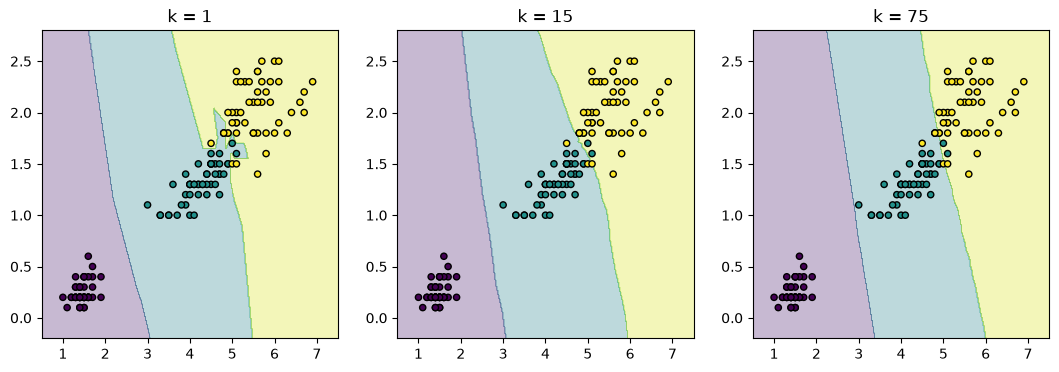

In [9]:
X2 = X[:, 2:4]
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
xx, yy = np.meshgrid(np.linspace(0.5, 7.5, 300), np.linspace(-0.2, 2.8, 300))
gitter = np.c_[xx.ravel(), yy.ravel()]
for ax, k in zip(axes, [1, 15, 75]):
    m = KNeighborsClassifier(n_neighbors=k).fit(X2, y)
    zz = m.predict(gitter).reshape(xx.shape)
    ax.contourf(xx, yy, zz, alpha=0.3, cmap="viridis")
    ax.scatter(X2[:, 0], X2[:, 1], c=y, cmap="viridis", edgecolor="k", s=20)
    ax.set_title(f"k = {k}")
plt.show()

## Zusammenfassung

- Ein Datensatz ist eine Matrix `X` (Beispiele × Features) plus ein Label-Vektor `y`.
- scikit-learn: `fit` zum Trainieren, `predict` für Vorhersagen, `score` für eine Standardmetrik.
- Bewertet wird **immer** auf Daten, die das Modell nicht gesehen hat.
- Hyperparameter wie `k` steuern, wie flexibel ein Modell ist – zu flexibel → Overfitting, zu starr → Underfitting.